In [2]:
%run ../setup.py
%load_ext autoreload
%autoreload 2
# ============= 
import pandas as pd
import numpy as np
# ============= METRICS ===========================
from sklearn.metrics import (mean_absolute_error, 
                            mean_absolute_percentage_error, 
                            mean_squared_error)
# ============= TTIME SERIES =======================
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
# ============= ARIMA MODEL =======================
from statsmodels.tsa.arima.model import ARIMA
# ============= DATA TIME SERIES ==================
from utils.data_loader import load_timeseries_data
# ============= VISUALIZE AND CONFIG PARAMS =======
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.figsize': (12, 8),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
    'lines.linewidth': 2,
    'grid.alpha': 0.3,
    'savefig.dpi': 300,
})
# ============= TURN OFF THE WARNING ==============
import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 0. LOAD DATA

In [3]:
df = load_timeseries_data()

# 1. Seasonal Decompose
Phân rã bằng mô hình cộng và chọn chu kì = 4 (~ 1 tháng)

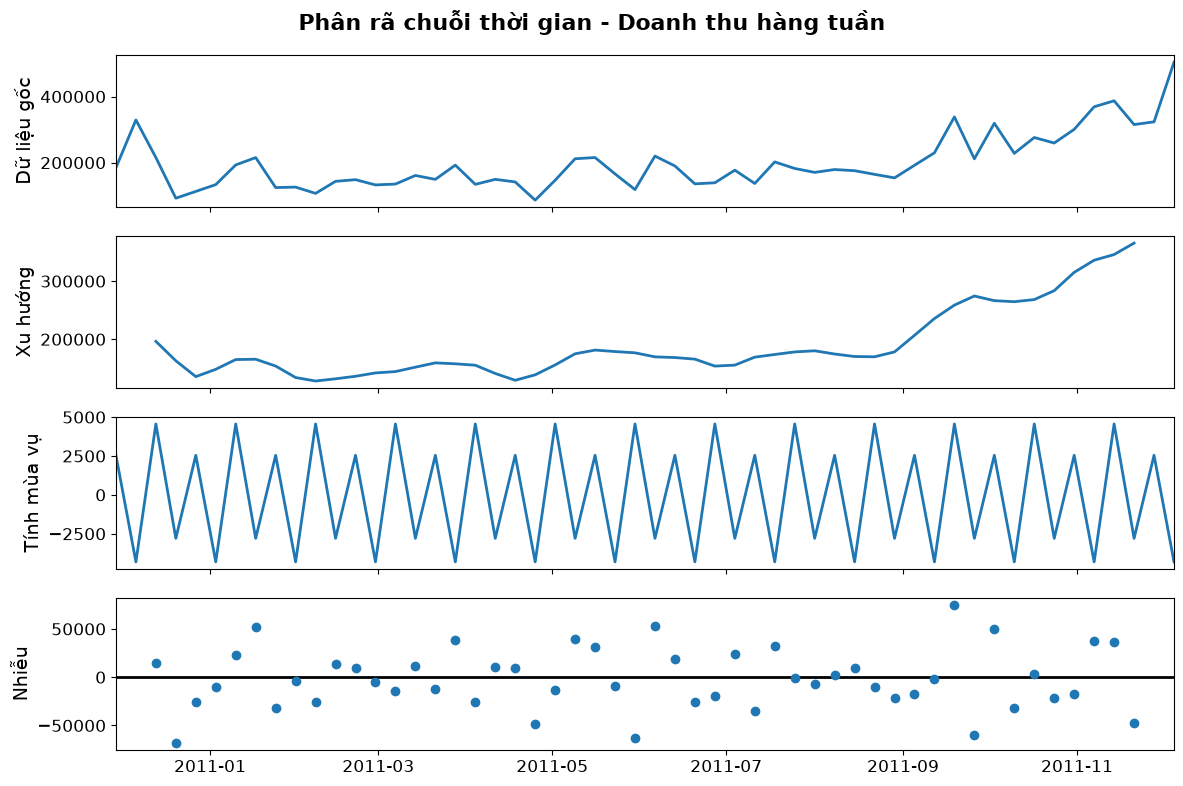

In [4]:
decomposition = seasonal_decompose(df, model='additive', period=4)

fig = decomposition.plot()

fig.suptitle('Phân rã chuỗi thời gian - Doanh thu hàng tuần', fontsize=16, fontweight='bold')
fig.subplots_adjust(top=0.93) 

axes = fig.axes
axes[0].set_ylabel('Dữ liệu gốc')
axes[1].set_ylabel('Xu hướng')
axes[2].set_ylabel('Tính mùa vụ')
axes[3].set_ylabel('Nhiễu')

plt.tight_layout()
plt.show()

# 2. Stationary

In [5]:
def find_d(df, alpha=0.05) -> tuple:
    """
    Hàm tìm ngưỡng d để bộ dữ liệu có tính dừng
    Trả về tuple: (DataFrame, d_value)
    """
    df_diff = df.copy()
    d = 0
    
    while True:
        p_value = adfuller(df_diff.dropna())[1]
        if p_value < alpha:
            break
        else:
            d += 1
            df_diff = df_diff.diff()

        if d > 3:
            print('Đã sai phân quá 3 lần -> Dữ liệu sẽ mất thông tin nên dừng')
            break
    return (df_diff, d)

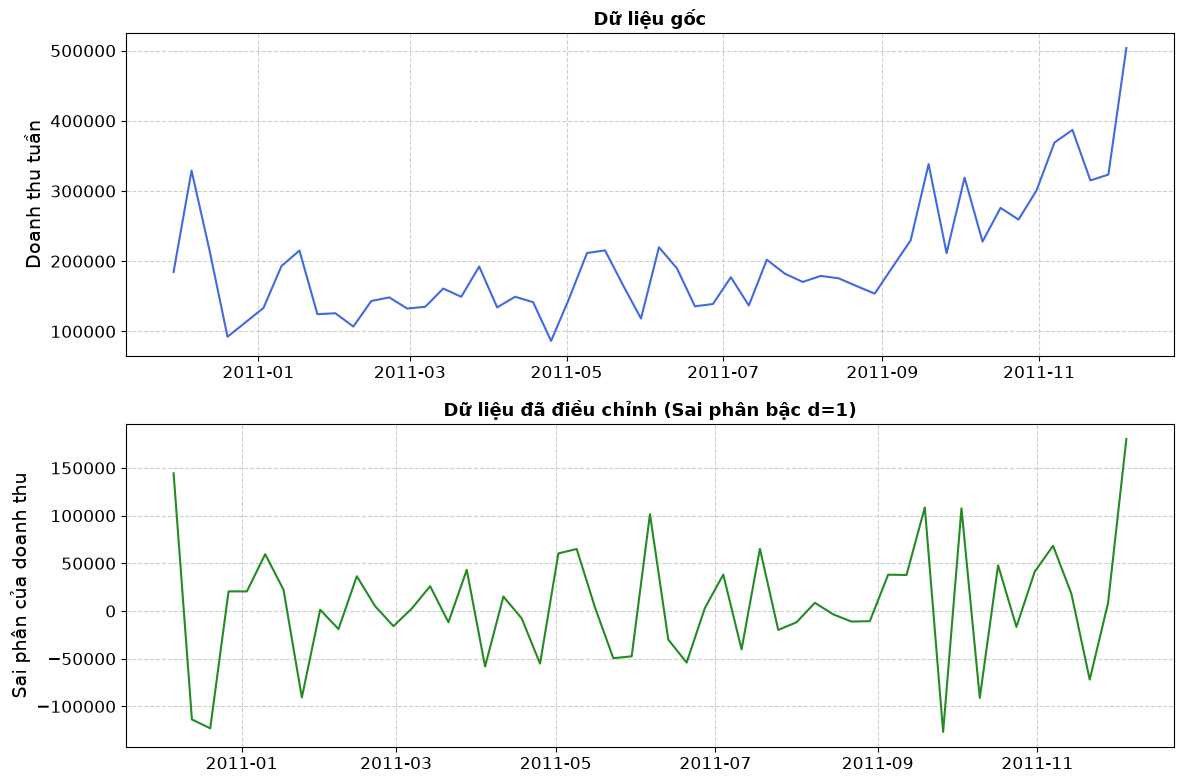

In [6]:
fig, (ax1, ax2) = plt.subplots(2,1)

ax1.plot(df, color='royalblue', linewidth=1.5)
ax1.set_title('Dữ liệu gốc', fontsize=13, fontweight='bold')
ax1.set_ylabel('Doanh thu tuần')
ax1.grid(True, linestyle='--',alpha=0.6)

df_diff, d = find_d(df)
ax2.plot(df_diff, color='forestgreen', linewidth=1.5)
ax2.set_title(f'Dữ liệu đã điều chỉnh (Sai phân bậc d={d})', fontsize=13, fontweight='bold')
ax2.set_ylabel('Sai phân của doanh thu')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. ADF and PACF

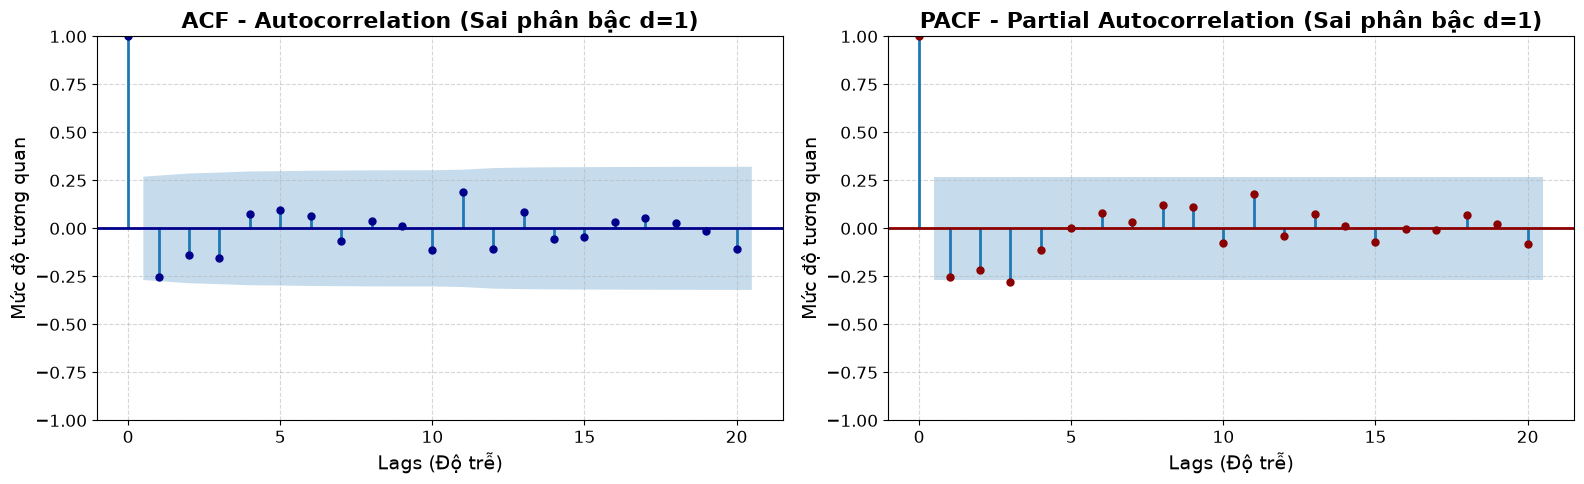

In [7]:
def plot_acf_pacf(df_diff, d):
    """
    Vẽ biểu đồ ACF và PACF trên chuỗi dữ liệu đã dừng.
    """
    df_diff = df_diff.dropna()
    
    fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    plot_acf(df_diff, lags=20, ax=ax1, color='darkblue')
    ax1.set_title(f'ACF - Autocorrelation (Sai phân bậc d={d})', fontweight='bold')
    ax1.set_xlabel('Lags (Độ trễ)')
    ax1.set_ylabel('Mức độ tương quan')
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    plot_pacf(df_diff, lags=20, ax=ax2, color='darkred')
    ax2.set_title(f'PACF - Partial Autocorrelation (Sai phân bậc d={d})', fontweight='bold')
    ax2.set_xlabel('Lags (Độ trễ)')
    ax2.set_ylabel('Mức độ tương quan')
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

plot_acf_pacf(df_diff, d)

# 4. Build Model ARIMA
Sử dụng với bộ tham số (p,d,q) = (1,1,1)

In [8]:
from itertools import product
def optimize_arima(series, p_values, d_value, q_values) -> list[int]:
    """
    Hàm tìm tham số (p,d,q) tối ưu dựa trên AIC nhỏ nhất
    Method: Brute Force
    """
    pdq = list(product(range(p_values + 1), [d_value], range(q_values + 1)))

    best_aic = float("inf")
    best_order = None
    results_list = []
    
    for param in pdq:
        try:
            model = ARIMA(series, order=param)
            model_fit = model.fit()
            aic = model_fit.aic
            results_list.append((param, aic))
            
            if aic < best_aic:
                best_aic = aic
                best_order = param
        except Exception as e:
            continue
            
    results_df = pd.DataFrame(results_list, columns=['(p, d, q)', 'AIC']).sort_values(by='AIC')
    print(results_df.to_string(index=False))
    print(f"\n=> Tham số TỐI ƯU NHẤT (AIC thấp nhất) là: ARIMA{best_order} với AIC = {best_aic:.2f}")
    
    return best_order

In [9]:
test_size = 10
train = df.iloc[:len(df)-test_size]
best_params = optimize_arima(train, p_values = 1, d_value = 1, q_values = 1)

(p, d, q)         AIC
(1, 1, 1) 1060.498206
(0, 1, 0) 1065.620846
(0, 1, 1) 1066.286140
(1, 1, 0) 1068.395730

=> Tham số TỐI ƯU NHẤT (AIC thấp nhất) là: ARIMA(1, 1, 1) với AIC = 1060.50


# 5. Đánh giá mô hình

In [10]:
from itertools import product
def evaluate_arima_methods(series, order, n_test=10):
    """
    Đánh giá khả năng học, hiểu và dự đoán của mô hình bằng 3 phương pháp
    1) Dự đoán tuần tự không học từ tương lai (Static)
    2) Học kéo dài chuỗi thời gian (EXPAND WINDOW)
    3) Học trong 1 phạm vi thời gian nhất định (SLIDING WINDOW)

    Return: DataFrame chứa từng chỉ số đánh giá cho từng Mô hình + Phương pháp
    """
    p,d,q = order
    orders = list(product(range(p + 1), [d], range(q + 1)))

    # 4 model x 3 method -> 12 dòng
    results = []

    n_total = len(series)
    n_train = n_total - n_test
    train   = series.iloc[:n_train]
    test    = series.iloc[n_train:].values

    for pdq in orders:
        _p, _d, _q = pdq
        model_name = f"ARIMA({_p},{_d},{_q})"
        print(f"Đang chạy model {model_name}")

        # ==========================================
        #          1. Phương pháp STATIC
        # ==========================================
        try:
            fit_static = ARIMA(train, order = pdq).fit()
            pred_static = fit_static.forecast(steps=n_test).values
            rmse_static = np.sqrt(mean_squared_error(test, pred_static))
            mae_static  = mean_absolute_error(test, pred_static)
            mape_static = mean_absolute_percentage_error(test, pred_static) * 100
            results.append({'model': model_name, 
                            'methode': 'Static',
                            'rmse' : rmse_static,
                            'mae' : mae_static,
                            'mape': mape_static})
        except Exception as e_static:
            print(f"Error fitting ARIMA model at STATIC: {e_static}")
        # ==========================================
        #        2. Phương pháp EXPAND WINDOW
        # ==========================================
        pred_exp = []
        history_exp = list(train.values)
        try:
            for t in range(n_test):
                fit_exp = ARIMA(history_exp, order = pdq).fit()
                pred_exp.append(fit_exp.forecast(steps=1)[0])
                history_exp.append(test[t])
            rmse_exp = np.sqrt(mean_squared_error(test, pred_exp))
            mae_exp  = mean_absolute_error(test, pred_exp)
            mape_exp = mean_absolute_percentage_error(test, pred_exp) * 100
            results.append({'model': model_name, 
                            'methode': 'Expand Window',
                            'rmse' : rmse_exp,
                            'mae' : mae_exp,
                            'mape': mape_exp})
        except Exception as e_expWin:
            print(f"Error fitting ARIMA model at EXPAND WINDOW: {e_expWin}")

        # ==========================================
        #        3. Phương pháp SLIDING WINDOW
        # ==========================================
        pred_slide = []
        history_slide = list(train.values)
        window = len(train)
        try:
            for t in range(n_test):
                fit_slide = ARIMA(history_slide[-window:], order = pdq).fit()
                pred_slide.append(fit_slide.forecast(steps=1)[0])
                history_slide.append(test[t])
            rmse_slide = np.sqrt(mean_squared_error(test, pred_slide))
            mae_slide  = mean_absolute_error(test, pred_slide)
            mape_slide = mean_absolute_percentage_error(test, pred_slide) * 100
            results.append({'model': model_name, 
                            'methode': 'Sliding Window',
                            'rmse' : rmse_slide,
                            'mae' : mae_slide,
                            'mape': mape_slide})
        except Exception as e_rolWin:
            print(f"Error fitting ARIMA model at ROLLING WINDOW: {e_rolWin}")

    return pd.DataFrame(results).sort_values(by='rmse', ascending=True)

In [11]:
order = (1,1,1) # Ngưỡng tham số tối đa
df_results = evaluate_arima_methods(df, order)
df_results

Đang chạy model ARIMA(0,1,0)
Đang chạy model ARIMA(0,1,1)
Đang chạy model ARIMA(1,1,0)
Đang chạy model ARIMA(1,1,1)


,model,methode,rmse,mae,mape
5,"ARIMA(0,1,1)",Sliding Window,79613.699768,60801.563189,16.836188
8,"ARIMA(1,1,0)",Sliding Window,79716.868469,60499.478449,17.199131
11,"ARIMA(1,1,1)",Sliding Window,80585.966275,61831.091798,17.230196
7,"ARIMA(1,1,0)",Expand Window,81036.457426,63059.833903,18.609978
1,"ARIMA(0,1,0)",Expand Window,81814.460540,65163.316900,19.559135
2,"ARIMA(0,1,0)",Sliding Window,81814.460540,65163.316900,19.559135
4,"ARIMA(0,1,1)",Expand Window,83265.044683,63007.842532,17.303868
10,"ARIMA(1,1,1)",Expand Window,87115.758756,69378.915309,19.641035
0,"ARIMA(0,1,0)",Static,138082.115894,116692.127000,32.612744
6,"ARIMA(1,1,0)",Static,138722.186621,117448.789535,32.853892


In [16]:
def plot_results(df):
    """
    Hàm trực quan hóa kết quả đánh giá các mô hình
    Hình 1: Kết quả theo sai số RMSE và MAE
    Hình 2: Kết quả theo độ gần của MAPE
    """
    df_mi = df.set_index(['model','methode']).sort_index()

    # Chỉ lưu cấu hình -> idx[0][5:]
    # không cần ghi cửa sổ -> idx[1][:-6]
    format_label = lambda idx: f"{idx[0][5:]}\n{idx[1][:-7] if idx[1] != 'Static' else idx[1]}"

    sns.set_theme(style="whitegrid")
    color_rmse = '#34495E'  # Màu xanh xám đậm (dành cho RMSE)
    color_mae  = '#E67E22'  # Màu cam gạch (dành cho MAE)
    color_mape = '#16A085'  # Màu xanh ngọc lục (dành cho MAPE)

    fig, (ax1,ax2) = plt.subplots(2,1)
    # ===============================================
    #       BIỂU ĐỒ 1: RMSE và MAE nằm cạnh nhau
    # ===============================================
    df_rmse = df_mi.sort_values(by='rmse')
    x_labels_rmse = df_rmse.index.map(format_label)


    df_rmse[['rmse', 'mae']].plot(
        kind='bar', 
        ax=ax1, 
        color=[color_rmse, color_mae], 
        width=0.75
    )

    ax1.set_title('SO SÁNH SAI SỐ RMSE VÀ MAE THEO MÔ HÌNH VÀ PHƯƠNG PHÁP', 
                  fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel('Mô hình & Phương pháp', fontsize=12, fontweight='bold', labelpad=10)
    ax1.set_ylabel('Giá trị Sai số (£)', fontsize=12, fontweight='bold')
    
    ax1.set_xticklabels(x_labels_rmse, rotation=0, ha='center', fontsize=10)
    ax1.legend(['RMSE', 'MAE'], frameon=True)

    # ===============================================
    # BIỂU ĐỒ 2: Đồ thị cột dành riêng cho MAPE
    # ===============================================
    df_mape = df_mi.sort_values(by='mape')
    x_labels_mape = df_mape.index.map(format_label)

    df_mape['mape'].plot(
        kind='bar', 
        ax=ax2, 
        color=color_mape, 
        width=0.5
    )
    
    ax2.set_title('CHỈ SỐ PHẦN TRĂM SAI SỐ TUYỆT ĐỐI TRUNG BÌNH (MAPE %)', 
                  fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('Mô hình & Phương pháp', fontsize=12, fontweight='bold', labelpad=10)
    ax2.set_ylabel('MAPE (%)', fontsize=12, fontweight='bold')
    
    ax2.set_xticklabels(x_labels_mape, rotation=0, ha='center', fontsize=10)
    ax2.legend(['MAPE (%)'], frameon=True)
    
    plt.tight_layout()
    plt.show()


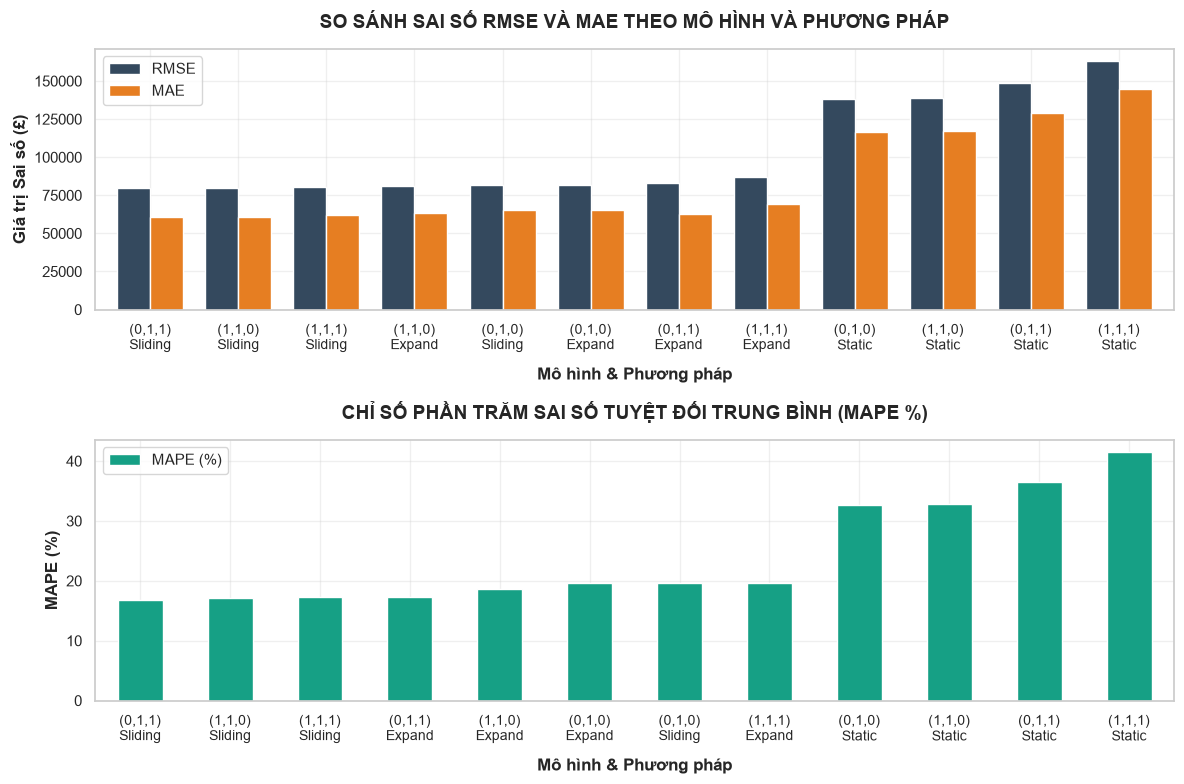

In [17]:
plot_results(df_results)

Dựa trên bảng số liệu, ta xác định lựa chọn mô hình ARIMA(0,1,1) với phương pháp dự đoán là Sliding Window

# 6. Dự đoán tương lai

DỰ BÁO DOANH THU VÀO TUẦN SAU - 2011-12-12: 417,499$


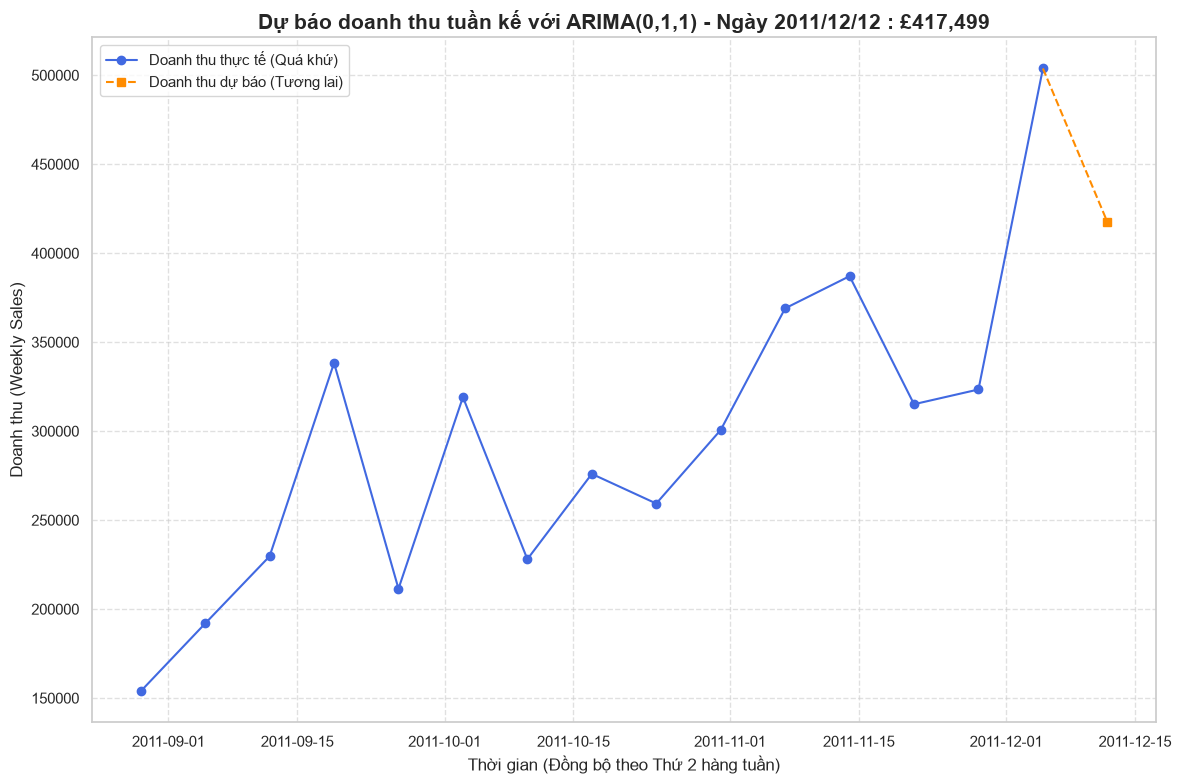

In [15]:
order  = (0,1,1)
window = len(train)

final_model = ARIMA(df['Weekly_Sales'][-window:], order=order).fit()

# Dự đoán tuần sau
steps = 1
forecast_values = final_model.forecast(steps=steps)

# Xác định thời gian tuần sau
last_date = df.index[-1]
future_date = pd.date_range(start=last_date + pd.Timedelta(days=7), periods=steps, freq='W-MON')
forecast_series = pd.Series(forecast_values.values, index=future_date)

for date, value in forecast_series.items():
    print(f"DỰ BÁO DOANH THU VÀO TUẦN SAU - {date.strftime('%Y-%m-%d')}: {value:,.0f}$")

# Vẽ biểu đồ
plt.plot(df.index[-15:], df['Weekly_Sales'].iloc[-15:], label='Doanh thu thực tế (Quá khứ)', marker='o', color='royalblue')

plt.plot(forecast_series.index, forecast_series, label='Doanh thu dự báo (Tương lai)', marker='s', color='darkorange', linestyle='--')

plt.plot([df.index[-1], forecast_series.index[0]], 
         [df['Weekly_Sales'].iloc[-1], forecast_series.iloc[0]], 
         color='darkorange', linestyle='--')

# Trích xuất ngày và giá trị dự báo
forecast_date = forecast_series.index[0].strftime('%Y/%m/%d')
forecast_val = forecast_series.iloc[0]

plt.title(f"Dự báo doanh thu tuần kế với ARIMA(0,1,1) - Ngày {forecast_date} : £{forecast_val:,.0f}", fontsize=15, fontweight='bold')
plt.xlabel('Thời gian (Đồng bộ theo Thứ 2 hàng tuần)', fontsize=12)
plt.ylabel('Doanh thu (Weekly Sales)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()